In [4]:
from gensim.models.ldamodel import LdaModel
import string
import spacy
from spacy.lang.en import English
parser = English()
#spacy.load('en')
import gensim 

In [2]:
!pip install -U spacy


In [5]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\exw974\AppData\Roaming\nltk_data...


True

## Tokenize the text using NLTK parser

In [6]:
#Tokenize the texxt 
def tokenize(text):
    lda_tokens = []
    tokens = parser(text)
    for token in tokens:
        if token.orth_.isspace():
            continue
        elif token.like_url:
            lda_tokens.append('URL')
        elif token.orth_.startswith('@'):
            lda_tokens.append('SCREEN_NAME')
        else:
            lda_tokens.append(token.lower_)
    return lda_tokens

## Lemmatize words using WordNetLemmatizer 

In [7]:
#Lemmatization using WordNetLemmatizer 
from nltk.stem.wordnet import WordNetLemmatizer
def WordNetlemma(word):
    return WordNetLemmatizer().lemmatize(word)

## Create a custom stop words list, combined from a number of different sources

In [8]:
# function to check if a line is blank
def isLineEmpty(line):
    return len(line.strip()) == 0

custom_stop_words = []
with open( "newStopwords.txt", "r" ) as fin:
    for line in fin.readlines():
        if not isLineEmpty(line):
            custom_stop_words.append( line.strip() )
print("Stopword list has %d entries" % len(custom_stop_words) )
 

Stopword list has 599 entries


## Pre-process the text for LDA

In [11]:
#punctuation= set(string.punctuation) 
def prepare_text_for_lda(text):
    tokens = tokenize(text)
    tokens = [token for token in tokens if len(token) > 3]   
    tokens = [token for token in tokens if token not in custom_stop_words]
    tokens = [WordNetlemma(token) for token in tokens]
    return tokens

In [12]:
text_data = []
with open('nytimes_articles.csv') as f:
    for line in f:
        tokens = prepare_text_for_lda(line)
        text_data.append(tokens)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 318: character maps to <undefined>

## Create a Gensim Dictionary

In [9]:
from gensim import corpora
dictionary = corpora.Dictionary(text_data)

In [ ]:
# display the Dictionary
#count = 0
#for k, v in dictionary.iteritems():
#    print(k, v)
#    count += 1
#   if count > 10:
#       break

### Create a Gensim Bag of Words  

In [10]:
corpus = [dictionary.doc2bow(text) for text in text_data]


### Save the Dictionary and the Corpus for later use

In [11]:
import pickle
pickle.dump(corpus, open('corpus.pkl', 'wb'))
dictionary.save('dictionary.gensim')

### Set up a function for computing Coherence Values

In [12]:
from gensim.models.coherencemodel import CoherenceModel
def compute_coherence_values(dictionary, corpus, texts, randomst, start=10, limit=30, step=4):
    """
    Compute c_v coherence for various number of topics

    Parameters:
    ----------
    dictionary : Gensim dictionary
    corpus : Gensim corpus
    texts : List of input texts
    limit : Max num of topics

    Returns:
    -------
    model_list : List of LDA topic models
    coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    """
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model=LdaModel(corpus=corpus, id2word=dictionary, random_state=randomst, num_topics=num_topics)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

### Run the Gensim LDAmodel via the function to find out the best coherence value with model with the number of topics setting from 10 to 30 by every 4 steps

In [13]:
model_list, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=text_data, randomst=123, start=10, limit=30, step=4)


In [16]:
# Display actual Coherence Scores and Models
model_list
coherence_values 

[0.4667097775711241,
 0.5685453326055369,
 0.5305744417281896,
 0.47593993128542106,
 0.49372925790450634]

### Visualize the Coherence Scores in a Plot

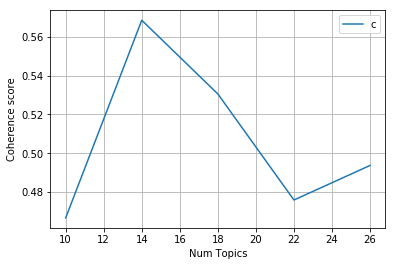

In [18]:
# Show graph

import matplotlib.pyplot as plt
limit=30; start=10; step=4;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.grid(True)
plt.show()

### Based on the coherence values, display 14 topics, the highest topic coherence value

In [19]:
import gensim
ldamodel14 = LdaModel(corpus, num_topics = 14, id2word=dictionary, random_state = 123, passes=15, iterations=500)
ldamodel14.save('model14.gensim')
topics = ldamodel14.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.008*"court" + 0.008*"police" + 0.005*"people" + 0.005*"officer" + 0.005*"official" + 0.004*"federal" + 0.004*"lawyer" + 0.004*"department" + 0.004*"judge" + 0.004*"justice"')
(1, '0.019*"trump" + 0.011*"republican" + 0.010*"clinton" + 0.010*"campaign" + 0.010*"party" + 0.010*"president" + 0.007*"obama" + 0.007*"political" + 0.006*"election" + 0.006*"vote"')
(2, '0.010*"time" + 0.008*"people" + 0.006*"life" + 0.005*"woman" + 0.004*"world" + 0.004*"something" + 0.003*"story" + 0.003*"family" + 0.003*"friend" + 0.003*"look"')
(3, '0.016*"game" + 0.014*"team" + 0.013*"player" + 0.012*"inning" + 0.012*"league" + 0.008*"mets" + 0.008*"sport" + 0.007*"run" + 0.007*"season" + 0.007*"home"')
(4, '0.033*"game" + 0.017*"season" + 0.016*"team" + 0.010*"series" + 0.009*"player" + 0.007*"yankee" + 0.006*"time" + 0.006*"coach" + 0.006*"playoff" + 0.006*"play"')
(5, '0.014*"government" + 0.014*"united" + 0.011*"country" + 0.010*"military" + 0.010*"official" + 0.010*"american" + 0.008*"attack" +

### Compute Perplexity and Coherence Score using the optimal 14 topics

In [21]:
from gensim.models.coherencemodel import CoherenceModel
# Compute Perplexity
print('\nPerplexity: ', round(ldamodel14.log_perplexity(corpus),2))  # a measure of how good the model is. lower the better.

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=ldamodel14, texts=text_data, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', round(coherence_lda,2))


Perplexity:  -9.6

Coherence Score:  0.59


### Display the intertopic distance map via multi-dimensional scaling using pyLDAvis

In [23]:
dictionary = gensim.corpora.Dictionary.load('dictionary.gensim')
corpus = pickle.load(open('corpus.pkl', 'rb'))
lda14 = gensim.models.ldamodel.LdaModel.load('model14.gensim')

In [26]:
import pyLDAvis.gensim
lda_display14 = pyLDAvis.gensim.prepare(lda14, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display14)

/home/cc/.local/lib/python3.5/site-packages/pyLDAvis/_prepare.py:257: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  return pd.concat([default_term_info] + list(topic_dfs))


### Visualize the topics in Word Clouds plots

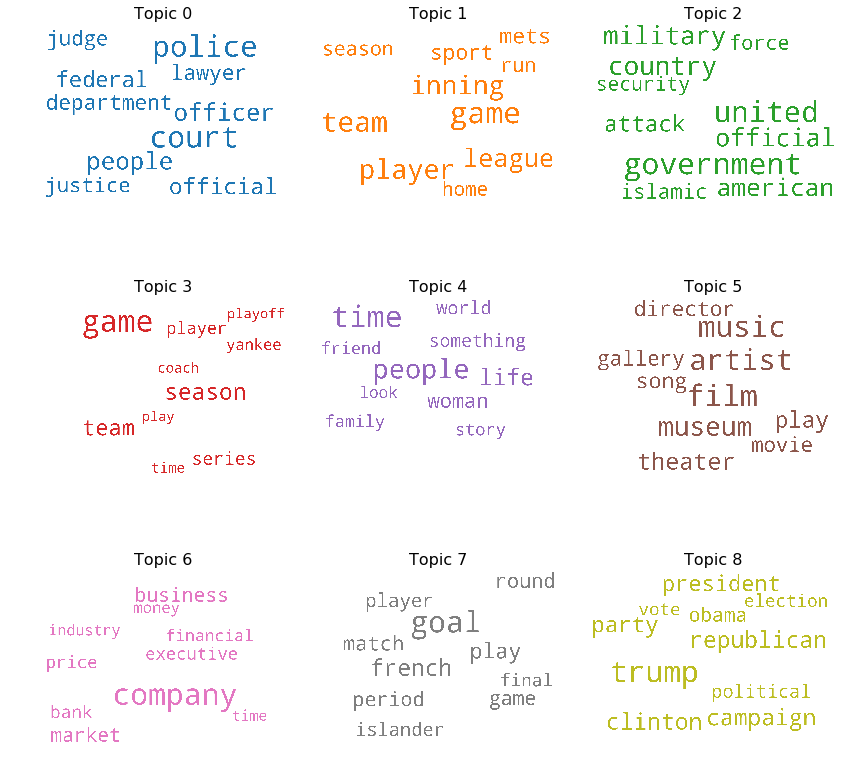

In [28]:
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  # more colors: 'mcolors.XKCD_COLORS'

cloud = WordCloud(stopwords=custom_stop_words,
                  background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics = ldamodel14.show_topics(formatted=False)

fig, axes = plt.subplots(3,3, figsize=(12,12), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=300)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()